In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv("claimants.csv")
df.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [3]:
df.shape

(1340, 7)

In [4]:
len(df["CASENUM"].unique())

1283

In [5]:
df.drop(["CASENUM"],inplace=True,axis=1)

In [6]:
df.isnull().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [7]:
df=df.dropna()

In [8]:
df.shape

(1096, 6)

In [9]:
x=df.iloc[:,1:]
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [10]:
y=df.iloc[:,0]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x_train.shape ,x_test.shape

((876, 5), (220, 5))

In [14]:
y_train.shape,y_test.shape

((876,), (220,))

In [15]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(x_train,y_train)

LogisticRegression()

In [16]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score
y_pred_test=classifier.predict(x_test)


In [17]:
accuracy_score(y_test,y_pred_test)


0.6772727272727272

In [18]:
classifier.predict_proba(x)

array([[9.99999654e-01, 3.45984944e-07],
       [4.85974592e-01, 5.14025408e-01],
       [4.00591883e-01, 5.99408117e-01],
       ...,
       [2.59655148e-01, 7.40344852e-01],
       [7.34762987e-01, 2.65237013e-01],
       [3.23400218e-01, 6.76599782e-01]])

In [19]:
confusion_matrix(y_test,y_pred_test)

array([[77, 34],
       [37, 72]])

In [20]:
roc_auc_score(y_test,classifier.predict_proba(x_test)[:,1])

np.float64(0.7212579552029093)

AUC Score: 0.7212579552029093


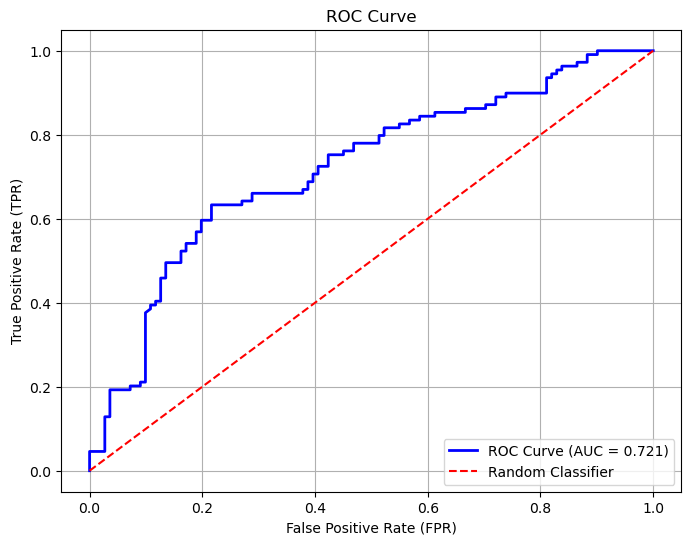

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


y_pred_probs = classifier.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

auc_score = roc_auc_score(y_test, y_pred_probs)

print("AUC Score:", auc_score)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         label='Random Classifier')

# Labels and Title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")

# Show Legend
plt.legend(loc="lower right")

# Grid
plt.grid(True)

# Display Plot
plt.show()

In [22]:
classifier=LogisticRegression(penalty="l2",C=0.1,solver="liblinear",random_state=42)
classifier.fit(x_train,y_train)

LogisticRegression(C=0.1, random_state=42, solver='liblinear')

l2=reduces overfitting by penalizing large coefficients


c=0.1 increse regularization Strength (lower c=Stronger penality)

In [23]:
from sklearn.feature_selection import RFE
selctor=RFE(classifier,n_features_to_select=3,step=1)
selctor.fit(x_train,y_train)
print("Selected features",x_train.columns[selctor.support_])

Selected features Index(['CLMSEX', 'CLMINSUR', 'LOSS'], dtype='object')


In [24]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(classifier,x_train,y_train,cv=5,scoring='accuracy')
cv_scores.mean(),cv_scores.std()


(np.float64(0.7146168831168831), np.float64(0.018337004697379436))